1.矢量化加速，提高处理速度的方法

In [1]:
import math
import time
import numpy as np
import torch
n = 10000
a = torch.ones([n])
b = torch.ones([n])

In [2]:
class Timer: #@save
	"""记录多次运行时间"""
	def __init__(self):
		self.times = []
		self.start()
	def start(self):
		"""启动计时器"""
		self.tik = time.time()
	def stop(self):
		"""停止计时器并将时间记录在列表中"""
		self.times.append(time.time()- self.tik)
		return self.times[-1]
	def avg(self):
		"""返回平均时间"""
		return sum(self.times) / len(self.times)
	def sum(self):
		"""返回时间总和"""
		return sum(self.times)
	def cumsum(self):
		"""返回累计时间"""
		return np.array(self.times).cumsum().tolist()

In [3]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.07575 sec'

In [4]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00033 sec'

通过对比发现矢量化代码确实可以提高运行速度


2. 正态分布与平方损失

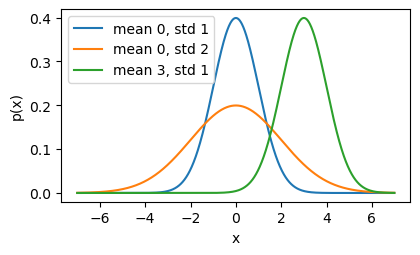

In [5]:
import matplotlib.pyplot as plt
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x- mu)**2)
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)
# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
plt.figure(figsize=(4.5, 2.5))
for mu, sigma in params:
    plt.plot(x, normal(x, mu, sigma), label=f'mean {mu}, std {sigma}')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()

生成数据集

In [6]:
def synthetic_data(w, b, num_examples): #@save
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [ ]:
#查看第一个样本的特征和标签
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([0.0778, 0.3034]) 
label: tensor([3.3266])


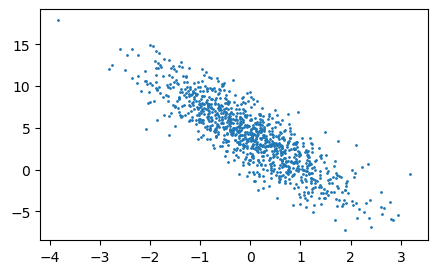

In [17]:
plt.figure(figsize=(5,3))
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)

生成data-iter函数


In [18]:
import random
def data_iter(batch_size, features,labels):
    num_examples= len(features)
    indices= list(range(num_examples))
    #这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.8675, -0.1984],
        [ 0.9389,  0.1880],
        [-1.7355,  0.8669],
        [-0.0724,  1.1349],
        [-0.1597, -1.0387],
        [ 1.7948, -0.5269],
        [-0.5374,  2.0225],
        [ 0.1221, -1.0237],
        [ 0.8676, -1.0943],
        [-0.2680,  1.2074]]) 
 tensor([[ 3.1362],
        [ 5.4418],
        [-2.2214],
        [ 0.1944],
        [ 7.4276],
        [ 9.5723],
        [-3.7582],
        [ 7.9058],
        [ 9.6554],
        [-0.4517]])


初始化模型参数

In [22]:
#形状为 (2,1) 的张量 w，其元素从均值为 0、标准差为 0.01 的正态分布中随机采样
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

定义模型

In [23]:
def linreg(X, w, b): #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

定义损失函数

In [24]:
def squared_loss(y_hat, y): #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2#除以2使得求导结果更简单

定义优化算法

In [25]:
def sgd(params, lr, batch_size): #params参数，lr学习率，batch_size批次大小
    """小批量随机梯度下降"""
    with torch.no_grad():#不需要计算梯度
        for param in params:
            param -= lr * param.grad / batch_size#平均梯度
            param.grad.zero_()#梯度清零

训练过程

In [26]:
lr = 0.03
num_epochs = 3
net = linreg#方便后续更换模型
loss = squared_loss
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()#求和计算梯度
        sgd([w, b], lr, batch_size)#使用参数梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')



epoch 1, loss 0.037736
epoch 2, loss 0.000136
epoch 3, loss 0.000050


In [27]:
print(f'w的估计误差: {true_w- w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b- b}')

w的估计误差: tensor([0.0004, 0.0004], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0009], grad_fn=<RsubBackward1>)
